## Load data and import packages

In [24]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.models as models
from torchvision.models import ResNet18_Weights
from dataloaders.data_loader_cropping_padding import CroppedPaddedDataset
from torch.utils.data import random_split, DataLoader
import matplotlib.pyplot as plt
import sys
import random
import math
sys.path.append("../dataloaders")

In [25]:
dataset = CroppedPaddedDataset("../Data/training_data/labels.csv", "../Data/training_data/images")

Image width 400 and height 200
Found 402 valid samples


## Simple CNN regression model

In [26]:
class CNNRegressor(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
        )

        self.gap = nn.AdaptiveAvgPool2d((1, 1))

        self.regressor = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.1),
            nn.Linear(64, 32),
            nn.ReLU(inplace=False),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.gap(x)
        x = self.regressor(x)
        return x

In [27]:
#Training and validation data
val_split = 0.2
n_total = len(dataset)
n_val = int(n_total * val_split)
n_train = n_total - n_val

train_set, val_set = random_split(dataset, [n_train, n_val])

train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
val_loader = DataLoader(val_set, batch_size=64, shuffle=False)

In [70]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model_CNN = CNNRegressor().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model_CNN.parameters(), lr=5e-4, weight_decay=1e-4)

num_epochs = 50
train_mse_list = []
val_mse_list = []
val_mae_list = []

for epoch in range(num_epochs):
    #Training
    model_CNN.train()
    running_loss = 0.0
    n = 0

    for imgs, labels, names in train_loader:
        imgs = imgs.to(device)
        labels = labels.float().view(-1, 1).to(device)

        optimizer.zero_grad()
        outputs = model_CNN(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        batch_size = imgs.size(0)
        running_loss += loss.item() * imgs.size(0)
        n += batch_size

    # print(f"Epoch {epoch+1}/{num_epochs} - Train MSE: {running_loss / n:.4f}")

    #Validation
    model_CNN.eval()
    val_loss = 0.0
    val_mae = 0.0
    n_val = 0

    with torch.no_grad():
        for imgs, labels, names in val_loader:
            imgs = imgs.to(device)
            labels = labels.float().view(-1, 1).to(device)

            outputs = model_CNN(imgs)

            #MSE
            loss = criterion(outputs, labels)
            val_loss += loss.item() * imgs.size(0)

            #MAE
            val_mae += torch.abs(outputs - labels).sum().item()

            n_val += imgs.size(0)

    train_mse = running_loss / n
    val_mse = val_loss / n_val
    val_mae_epoch = val_mae / n_val

    train_mse_list.append(train_mse)
    val_mse_list.append(val_mse)
    val_mae_list.append(val_mae_epoch)

# print(f"Val MSE: {val_loss / n_val:.4f} | Val MAE: {val_mae / n_val:.4f}")
    print(f"Epoch {epoch+1}/{num_epochs} "
      f"Train MSE: {train_mse:.4f} | "
      f"Val MSE: {val_mse:.4f} | "
      f"Val MAE: {val_mae_epoch:.4f}")

Using device: cuda
Epoch 1/50 Train MSE: 71.1459 | Val MSE: 50.8455 | Val MAE: 5.6421
Epoch 2/50 Train MSE: 68.2499 | Val MSE: 50.1714 | Val MAE: 5.5828
Epoch 3/50 Train MSE: 66.1011 | Val MSE: 48.7014 | Val MAE: 5.4630
Epoch 4/50 Train MSE: 64.4451 | Val MSE: 46.6077 | Val MAE: 5.2939
Epoch 5/50 Train MSE: 62.1911 | Val MSE: 44.4488 | Val MAE: 5.1267
Epoch 6/50 Train MSE: 60.2573 | Val MSE: 42.1771 | Val MAE: 4.9443
Epoch 7/50 Train MSE: 57.8467 | Val MSE: 39.6419 | Val MAE: 4.7500
Epoch 8/50 Train MSE: 55.3186 | Val MSE: 33.9730 | Val MAE: 4.2438
Epoch 9/50 Train MSE: 52.3538 | Val MSE: 29.7527 | Val MAE: 3.8170
Epoch 10/50 Train MSE: 49.5845 | Val MSE: 30.0838 | Val MAE: 3.8804
Epoch 11/50 Train MSE: 45.8613 | Val MSE: 29.4051 | Val MAE: 3.7885
Epoch 12/50 Train MSE: 42.3811 | Val MSE: 28.1311 | Val MAE: 3.7038
Epoch 13/50 Train MSE: 39.6601 | Val MSE: 21.6148 | Val MAE: 3.0093
Epoch 14/50 Train MSE: 36.1298 | Val MSE: 23.5398 | Val MAE: 3.2396
Epoch 15/50 Train MSE: 32.0284 | Val M

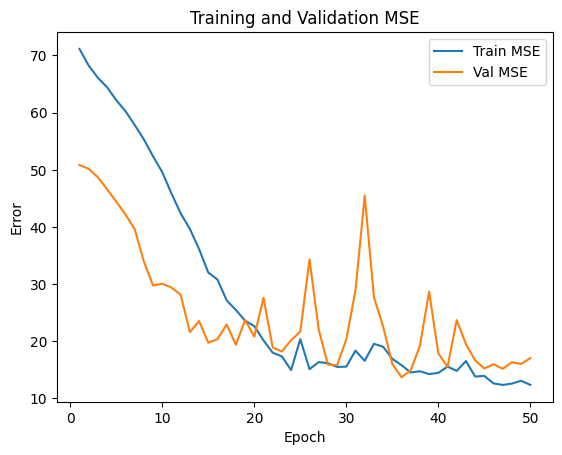

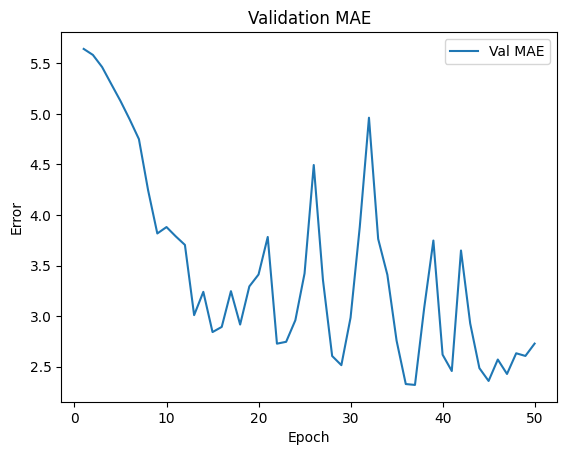

In [71]:
epochs = range(1, num_epochs + 1)
train_mse_list_CNN = train_mse_list
val_mse_list_CNN = val_mse_list
val_mae_list_CNN = val_mae_list

plt.plot(epochs, train_mse_list, label='Train MSE')
plt.plot(epochs, val_mse_list, label='Val MSE')
plt.xlabel('Epoch')
plt.ylabel('Error')
plt.legend()
plt.title('Training and Validation MSE')
plt.show()

plt.plot(epochs, val_mae_list, label='Val MAE')
plt.xlabel('Epoch')
plt.ylabel('Error')
plt.legend()
plt.title('Validation MAE')
plt.show()



## Edge Attention module

In [ ]:
class EdgeAttention(nn.Module):
    def __init__(self, in_channels=3):
        super().__init__()
        self.edge_conv = nn.Conv2d(in_channels, 8, kernel_size=5, padding=2)
        self.conv2 = nn.Conv2d(8, 8, kernel_size=5, padding=2)
        self.attention = nn.Conv2d(8, 1, kernel_size=1)

    def forward(self, x):
        # Edge extraction
        e = F.relu(self.edge_conv(x))
        e = F.relu(self.conv2(e))

        # Attention map (0~1)
        att = torch.sigmoid(self.attention(e))

        # Broadcast to 3 channels
        att = att.expand_as(x)

        # Apply attention
        return x * att, att


## Gabor Layer

In [ ]:
# class GaborLayer(nn.Module):
#     def __init__(self, in_channels=3, out_channels=8, kernel_size=11):
#         super().__init__()
#
#         self.in_channels = in_channels
#         self.out_channels = out_channels
#         self.kernel_size = kernel_size
#
#         # Gabor parameters
#         self.theta = nn.Parameter(torch.linspace(0, math.pi, out_channels))
#         self.lamda = nn.Parameter(torch.ones(out_channels) * 4.0)
#         self.sigma = nn.Parameter(torch.ones(out_channels) * 2.0)
#         self.gamma = nn.Parameter(torch.ones(out_channels) * 0.5)
#         self.psi = nn.Parameter(torch.zeros(out_channels))
#
#     def forward(self, x):
#
#         device = x.device
#         k = self.kernel_size
#
#         # coordinate grid
#         y, x_coord = torch.meshgrid(
#             torch.linspace(-1, 1, k, device=device),
#             torch.linspace(-1, 1, k, device=device),
#         )
#         grid = torch.stack([x_coord, y], dim=-1)  # (k, k, 2)
#
#         kernels = []
#         for i in range(self.out_channels):
#
#             theta = self.theta[i]
#             lamda = self.lamda[i]
#             sigma = self.sigma[i]
#             gamma = self.gamma[i]
#             psi = self.psi[i]
#
#             x_rot = grid[...,0] * torch.cos(theta) + grid[...,1] * torch.sin(theta)
#             y_rot = -grid[...,0] * torch.sin(theta) + grid[...,1] * torch.cos(theta)
#
#             # ---- GABOR FORMULA ----
#             gabor_filter = torch.exp(
#                 -0.5 * ((x_rot**2 + (gamma**2)*y_rot**2) / (sigma**2))
#             ) * torch.cos(2 * math.pi * x_rot / lamda + psi)
#
#             kernels.append(gabor_filter)
#
#         # shape: (out, 1, k, k)
#         kernels = torch.stack(kernels, dim=0).unsqueeze(1)
#
#         # repeat across channels
#         kernels = kernels.repeat(1, self.in_channels, 1, 1)
#
#         # use conv2d with manually generated kernels
#         return nn.functional.conv2d(
#             x, kernels, padding=self.kernel_size//2
#         )

## CNN Regressor With Edge Attention

In [72]:
class CNNRegressorWithEdge(nn.Module):
    def __init__(self, base_model):
        super().__init__()
        self.edge = EdgeAttention()
        self.base = base_model

    def forward(self, x):
        x, att = self.edge(x)
        out = self.base(x)
        return out, att

In [79]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

model = CNNRegressorWithEdge(CNNRegressor()).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4, weight_decay=1e-4)

num_epochs = 50

train_mse_list = []
val_mse_list = []
val_mae_list = []

for epoch in range(num_epochs):

    # -------- Train -------- #
    model.train()
    running_loss = 0.0
    n_train = 0

    for imgs, labels, names in train_loader:
        imgs = imgs.to(device)
        labels = labels.float().view(-1, 1).to(device)

        optimizer.zero_grad()

        preds, att = model(imgs)
        loss = criterion(preds, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        n_train += imgs.size(0)

    train_mse = running_loss / n_train
    train_mse_list.append(train_mse)

    # -------- Validation -------- #
    model.eval()
    val_loss = 0.0
    val_mae = 0.0
    n_val = 0

    with torch.no_grad():
        for imgs, labels, names in val_loader:
            imgs = imgs.to(device)
            labels = labels.float().view(-1, 1).to(device)

            preds, att = model(imgs)

            mse = criterion(preds, labels)
            val_loss += mse.item() * imgs.size(0)

            val_mae += torch.abs(preds - labels).sum().item()
            n_val += imgs.size(0)

    val_mse = val_loss / n_val
    val_mae_epoch = val_mae / n_val
    val_mse_list.append(val_mse)
    val_mae_list.append(val_mae_epoch)

    print(f"Epoch {epoch+1}/{num_epochs} "
          f"Train MSE: {train_mse:.4f} | "
          f"Val MSE: {val_mse:.4f} | "
          f"Val MAE: {val_mae_epoch:.4f}")

Using: cuda
Epoch 1/50 Train MSE: 68.6239 | Val MSE: 48.1817 | Val MAE: 5.4020
Epoch 2/50 Train MSE: 65.8903 | Val MSE: 47.3034 | Val MAE: 5.3228
Epoch 3/50 Train MSE: 63.7662 | Val MSE: 46.1375 | Val MAE: 5.2183
Epoch 4/50 Train MSE: 61.4292 | Val MSE: 44.7217 | Val MAE: 5.0984
Epoch 5/50 Train MSE: 59.5128 | Val MSE: 43.1248 | Val MAE: 4.9689
Epoch 6/50 Train MSE: 57.5314 | Val MSE: 41.6591 | Val MAE: 4.8569
Epoch 7/50 Train MSE: 54.7036 | Val MSE: 40.1212 | Val MAE: 4.7341
Epoch 8/50 Train MSE: 51.4418 | Val MSE: 38.0579 | Val MAE: 4.5683
Epoch 9/50 Train MSE: 48.2849 | Val MSE: 33.9813 | Val MAE: 4.2127
Epoch 10/50 Train MSE: 44.4227 | Val MSE: 28.3527 | Val MAE: 3.6700
Epoch 11/50 Train MSE: 42.1970 | Val MSE: 25.5105 | Val MAE: 3.3664
Epoch 12/50 Train MSE: 38.2014 | Val MSE: 19.4850 | Val MAE: 2.7189
Epoch 13/50 Train MSE: 33.8832 | Val MSE: 21.7881 | Val MAE: 2.9355
Epoch 14/50 Train MSE: 30.8008 | Val MSE: 22.6166 | Val MAE: 3.0680
Epoch 15/50 Train MSE: 29.3306 | Val MSE: 19.

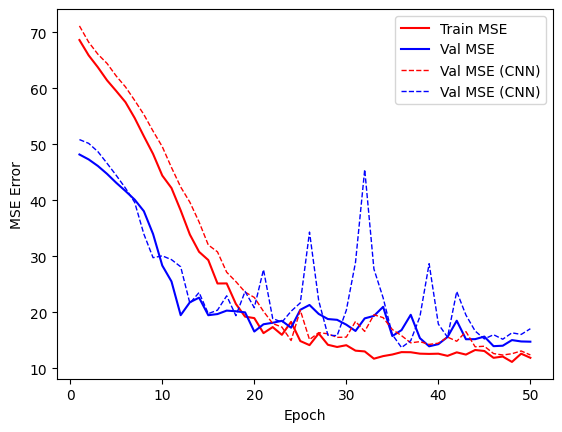

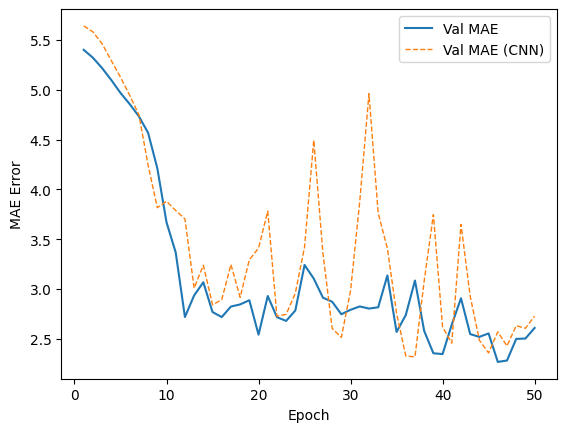

In [80]:
epochs = range(1, num_epochs + 1)

plt.plot(epochs, train_mse_list, label='Train MSE',color='red')
plt.plot(epochs, val_mse_list, label='Val MSE',color='blue')
plt.plot(epochs, train_mse_list_CNN, label='Val MSE (CNN)',color='red', linestyle='--', linewidth=1)
plt.plot(epochs, val_mse_list_CNN, label='Val MSE (CNN)',color='blue', linestyle='--', linewidth=1)
plt.xlabel('Epoch')
plt.ylabel('MSE Error')
plt.legend()
plt.show()

plt.plot(epochs, val_mae_list, label='Val MAE')
plt.plot(epochs, val_mae_list_CNN, label='Val MAE (CNN)',linestyle='--', linewidth=1)
plt.xlabel('Epoch')
plt.ylabel('MAE Error')
plt.legend()
plt.show()

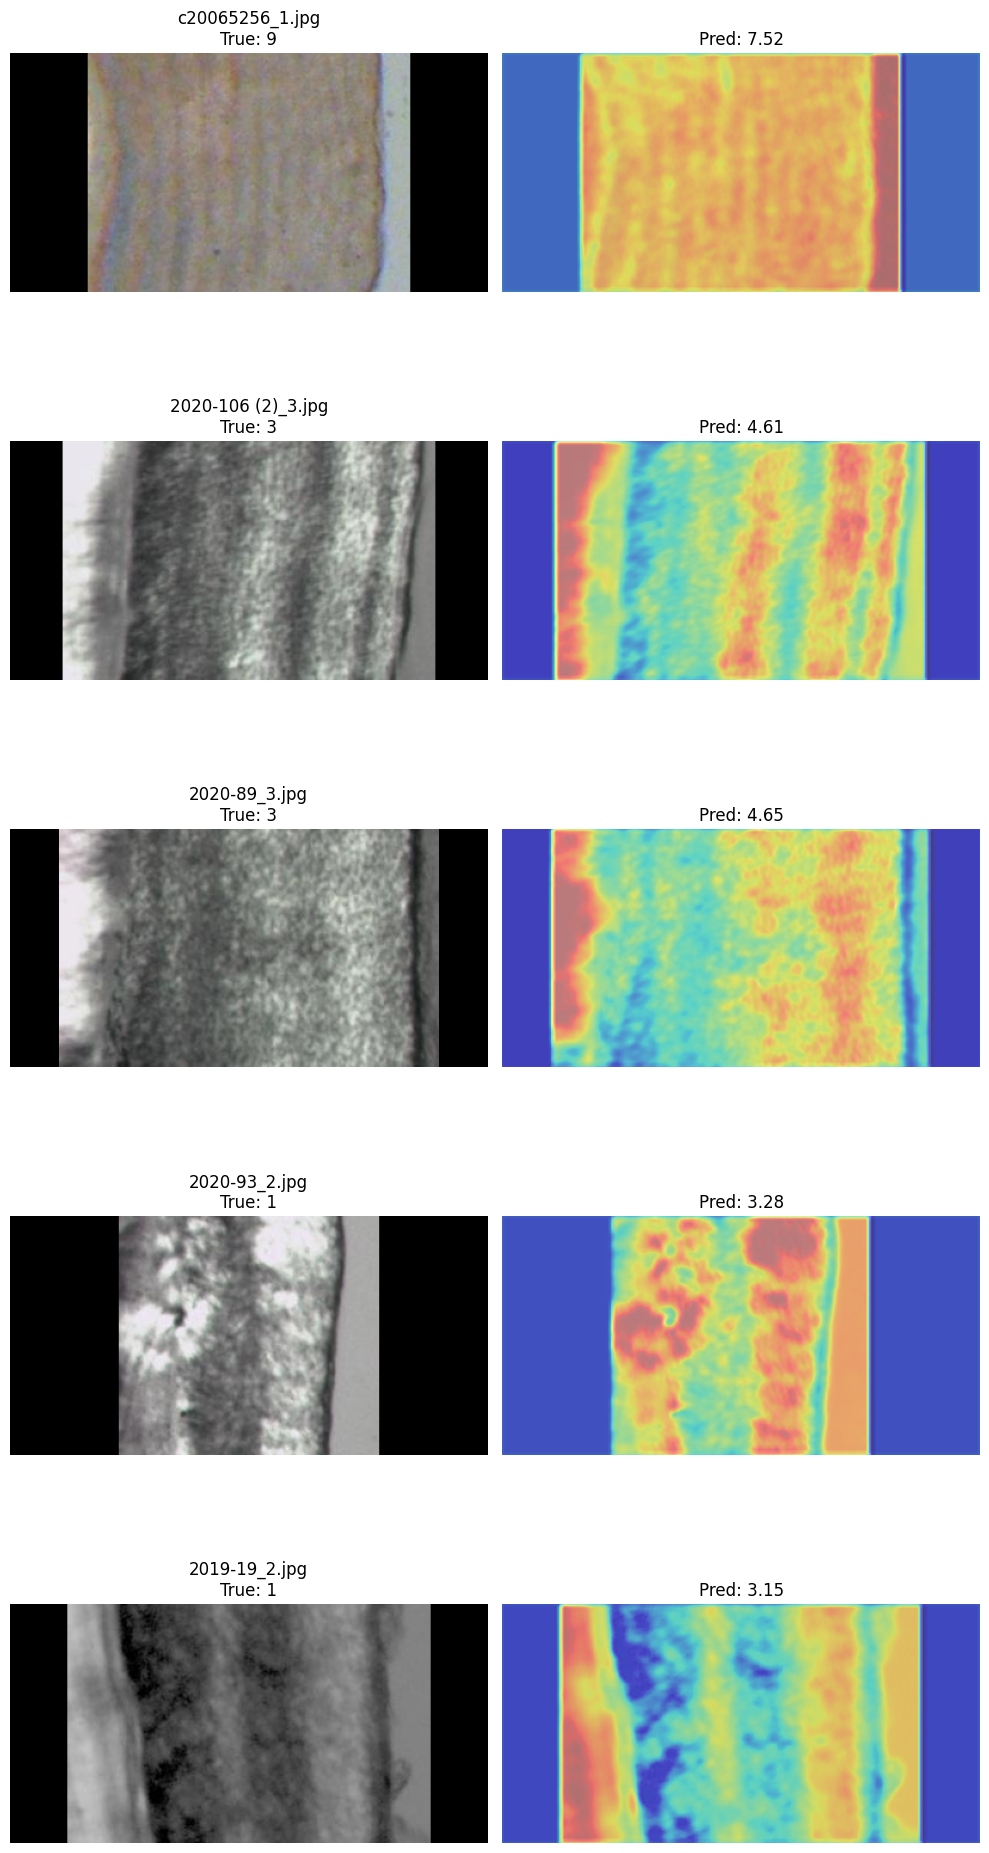

In [81]:
#visualization
num_images = 5

# random index
idxs = random.sample(range(len(dataset)), num_images)

plt.figure(figsize=(10, 4 * num_images))

for i, idx in enumerate(idxs):
    img, label, name = dataset[idx]
    img_batch = img.unsqueeze(0).to(device)

    with torch.no_grad():
        pred, att = model(img_batch)

    img_np = img_batch[0].cpu().permute(1, 2, 0).numpy()
    att_np = att[0, 0].cpu().numpy()
    att_np = (att_np - att_np.min()) / (att_np.max() - att_np.min() + 1e-8)

    # original images
    plt.subplot(num_images, 2, 2 * i + 1)
    plt.imshow(img_np)
    plt.title(f"{name}\nTrue: {label}")
    plt.axis("off")

    # Edge Attention visualization
    plt.subplot(num_images, 2, 2 * i + 2)
    plt.imshow(img_np, alpha=0.5)
    plt.imshow(att_np, cmap="jet", alpha=0.5)
    plt.title(f"Pred: {pred.item():.2f}")
    plt.axis("off")

plt.tight_layout()
plt.show()